In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("/content/loan.csv")

print(df.head())

   id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0 NaN        NaN       2500         2500             2500   36 months   
1 NaN        NaN      30000        30000            30000   60 months   
2 NaN        NaN       5000         5000             5000   36 months   
3 NaN        NaN       4000         4000             4000   36 months   
4 NaN        NaN      30000        30000            30000   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.56        84.92     C        C1  ...                            NaN   
1     18.94       777.23     D        D2  ...                            NaN   
2     17.97       180.69     D        D1  ...                            NaN   
3     18.94       146.51     D        D2  ...                            NaN   
4     16.14       731.78     C        C4  ...                            NaN   

  hardship_last_payment_amount disbursement_method  debt_settlement_flag  \
0   

In [4]:
df = df[['loan_amnt','term','int_rate','annual_inc',
         'emp_length','home_ownership','purpose',
         'grade','loan_status']]

In [5]:
df = df.dropna()

df = df[(df['loan_status'] == 'Fully Paid') |
        (df['loan_status'] == 'Charged Off')]

In [6]:
df['loan_status'] = df['loan_status'].replace({
    'Fully Paid': 0,
    'Charged Off': 1
})

df['term'] = df['term'].astype(str)
df['term'] = df['term'].str.replace(' months', '', regex=False)
df['term'] = pd.to_numeric(df['term'], errors='coerce')

df['int_rate'] = df['int_rate'].astype(str)
df['int_rate'] = df['int_rate'].str.replace('%', '', regex=False)
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

/tmp/ipykernel_23991/2049224936.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['loan_status'] = df['loan_status'].replace({


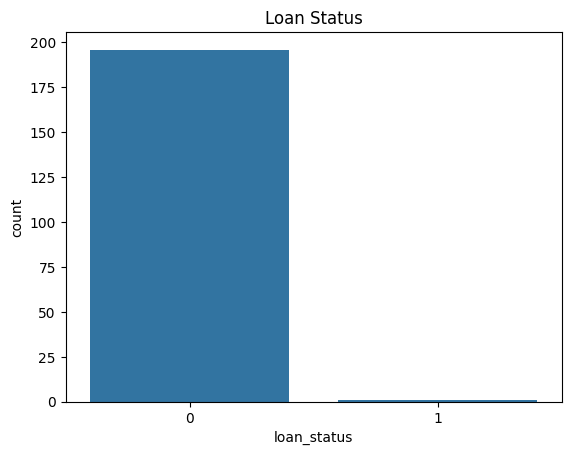

In [7]:
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status")
plt.show()

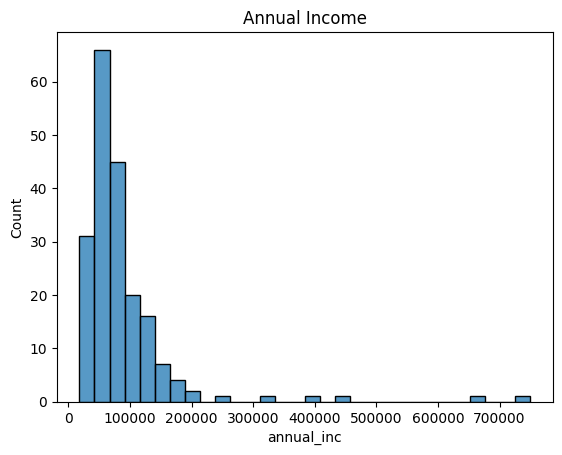

In [8]:
sns.histplot(df['annual_inc'], bins=30)
plt.title("Annual Income")
plt.show()

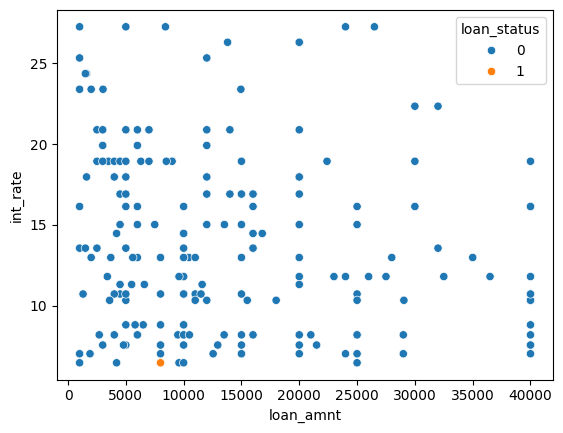

In [9]:
sns.scatterplot(x='loan_amnt',
                y='int_rate',
                hue='loan_status',
                data=df)
plt.show()

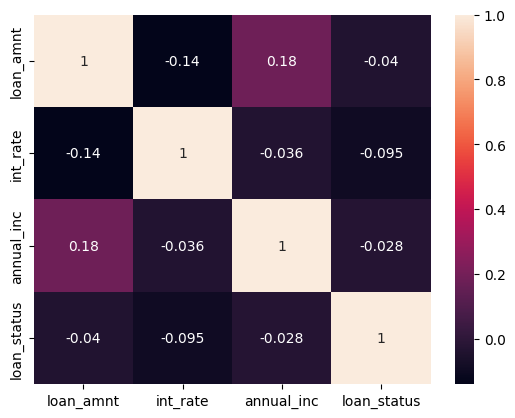

In [10]:
sns.heatmap(df[['loan_amnt','int_rate',
                'annual_inc',
                'loan_status']].corr(),
            annot=True)

plt.show()

In [11]:
X = df[['annual_inc','int_rate','term']]

In [12]:
y = df['loan_amnt']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
print("R2 Score :", r2_score(y_test, y_pred))

R2 Score : 0.17133284812591576
